# Notebook 04 — Thesis Figures
**Thesis:** Chapter 7 | **Input:** `data/2_events.csv`, `data/3_*.csv` | **Output:** `figures/fig_*.pdf + .png`

---

## Figure Map

| Figure | Content | Thesis section |
|--------|---------|---------------|
| Fig 7.1 | PDR decomposition — system → raw → link | §7.1.1 |
| Fig 7.2 | Loss zone breakdown | §7.1.1 |
| Fig 7.3 | Rolling PDR time series — all 6 devices | §7.1.2 |
| Fig 7.4 | CO₂ vs Rolling PDR dual axis (ED3) | §7.4 |
| Fig 7.5 | PDR by time of day — diurnal cycle | §7.3.2 |
| Fig 7.6 | CO₂ tier PDR + burst rate | §7.4 |
| Fig 7.7 | SF PDR + burst rate | §7.6.1 |
| Fig 7.8 | SF × CO₂ heatmap — headline novel finding | §7.6.2 |
| Fig 7.9 | Logistic regression forest plot — OR with 95% CI | §7.7 |

All figures saved as **PDF** (for Overleaf) and **PNG** (for checking).  
Upload the `figures/` folder to Overleaf and reference with `\includegraphics{figures/fig_7_X_name}`.

## 0 · Imports, IEEE Style & Load

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from pathlib import Path
import warnings; warnings.filterwarnings('ignore')

DATA_DIR = Path('../data')
FIG_DIR  = Path('../figures'); FIG_DIR.mkdir(exist_ok=True)

# IEEE-style settings — applied to all figures
plt.rcParams.update({
    'font.family':       'serif',
    'font.size':         10,
    'axes.titlesize':    11,
    'axes.labelsize':    10,
    'xtick.labelsize':   9,
    'ytick.labelsize':   9,
    'legend.fontsize':   9,
    'figure.dpi':        150,
    'savefig.dpi':       300,
    'savefig.bbox':      'tight',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.alpha':        0.3,
    'grid.linestyle':    '--',
})

# colourblind-safe palette
C = {
    'blue':   '#0077BB',
    'orange': '#EE7733',
    'green':  '#009988',
    'red':    '#CC3311',
    'purple': '#AA3377',
    'navy':   '#004488',
    'grey':   '#BBBBBB',
}
DEVICE_COLORS = [C['blue'], C['orange'], C['green'],
                 C['red'],  C['purple'], C['navy']]
TOA_MS = {7: 71.9, 8: 133.6, 9: 246.8, 10: 452.6}

def save_fig(fig, name):
    """Save as PDF (Overleaf) and PNG (preview)."""
    fig.savefig(FIG_DIR / f'{name}.pdf')
    fig.savefig(FIG_DIR / f'{name}.png')
    print(f'  Saved: {name}.pdf + .png')
    plt.close(fig)

# load datasets
df      = pd.read_csv(DATA_DIR / '2_events.csv')
df['time'] = pd.to_datetime(df['time'], utc=True)
df      = df.sort_values(['device_id','time']).reset_index(drop=True)
df_link = df[~df['is_outage'] & ~df['is_sf_artifact']].copy().reset_index(drop=True)
or_table = pd.read_csv(DATA_DIR / '3_odds_ratios.csv')

DEVICES = sorted(df['device_id'].unique())

def pdr(grp):
    rx = len(grp); lost = int(grp['mac_to_radio_loss'].sum())
    return rx / (rx + lost) * 100 if (rx + lost) > 0 else 0

def burst_rate(grp):
    return (grp['mac_to_radio_loss'] >= 3).mean() * 100

print(f'df       : {len(df):,} rows')
print(f'df_link  : {len(df_link):,} rows')
print(f'FIG_DIR  : {FIG_DIR.resolve()}')

df       : 1,217,313 rows
df_link  : 1,156,407 rows
FIG_DIR  : D:\Thesis\lorawan_master_thesis\figures


## 1 · Fig 7.1 — PDR Decomposition  *(§7.1.1)*

Three bars showing PDR_system → PDR_raw → PDR_link.  
Visualises the methodological contribution — stripping non-radio losses to reveal true reliability.

In [13]:
rx          = len(df)
lost_system = int(df['total_loss'].sum())
lost_raw    = int(df['mac_to_radio_loss'].sum())
lost_link   = int(df_link['mac_to_radio_loss'].sum())
pdr_system  = rx / (rx + lost_system) * 100
pdr_raw     = rx / (rx + lost_raw)    * 100
pdr_link    = len(df_link) / (len(df_link) + lost_link) * 100

labels = ['PDR_system\n(incl. app-MAC drops)', 'PDR_raw\n(radio, all losses)', 'PDR_link\n(radio, env. only)']
values = [pdr_system, pdr_raw, pdr_link]
colors = [C['red'], C['orange'], C['green']]

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(labels, values, color=colors, width=0.45, alpha=0.88, edgecolor='white')

for bar, v in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.5,
            f'{v:.2f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

# arrows showing the gaps
ax.annotate('', xy=(1, pdr_raw+1), xytext=(0, pdr_system+1),
            arrowprops=dict(arrowstyle='->', color='black', lw=1.2))
ax.annotate('', xy=(2, pdr_link+1), xytext=(1, pdr_raw+1),
            arrowprops=dict(arrowstyle='->', color='black', lw=1.2))

ax.set_ylabel('PDR (%)')
ax.set_title('Fig 7.1 — PDR Decomposition: System → Raw → Link')
ax.set_ylim(50, 102)
ax.axhline(y=100, color='grey', lw=0.5, ls=':')

fig.tight_layout()
save_fig(fig, 'fig_7_1_pdr_decomposition')

  Saved: fig_7_1_pdr_decomposition.pdf + .png


## 2 · Fig 7.2 — Loss Zone Breakdown  *(§7.1.1)*

Stacked bar showing what fraction of all intervals belongs to each loss zone.  
Visually explains WHY PDR jumps from 65% to 96% — the SF artifact dominates raw losses.

In [14]:
zones = ['no_loss', 'sf_artifact', 'radio_loss', 'ambiguous', 'outage']
labels_z = ['No loss', 'SF artifact', 'Radio loss\n(1–9)', 'Ambiguous\n(10–59)', 'Outage\n(≥60)']
colors_z  = [C['green'], C['orange'], C['blue'], C['grey'], C['red']]

counts = df['loss_zone'].value_counts().reindex(zones).fillna(0)
pcts   = counts / len(df) * 100

fig, ax = plt.subplots(figsize=(8, 4))
left = 0
for zone, label, color in zip(zones, labels_z, colors_z):
    w = pcts[zone]
    ax.barh(0, w, left=left, color=color, edgecolor='white', height=0.5, label=f'{label} ({w:.2f}%)')
    if w > 1.5:
        ax.text(left + w/2, 0, f'{w:.1f}%', ha='center', va='center',
                fontsize=8, fontweight='bold', color='white')
    left += w

ax.set_xlim(0, 100)
ax.set_yticks([])
ax.set_xlabel('Percentage of all intervals (%)')
ax.set_title('Fig 7.2 — Loss Zone Breakdown (all 1,217,313 intervals)')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.18), ncol=5, fontsize=8)

fig.tight_layout()
save_fig(fig, 'fig_7_2_loss_zone_breakdown')

  Saved: fig_7_2_loss_zone_breakdown.pdf + .png


## 3 · Fig 7.3 — Rolling PDR Time Series  *(§7.1.2)*

Rolling 30-minute PDR for each device across the full 34-week campaign.  
6 subplots stacked vertically — shared x-axis — each device in its own colour.  
Shows diurnal cycling, weekday/weekend contrast, seasonal drift, and burst episodes.

ValueError: passed window 30T is not compatible with a datetimelike index

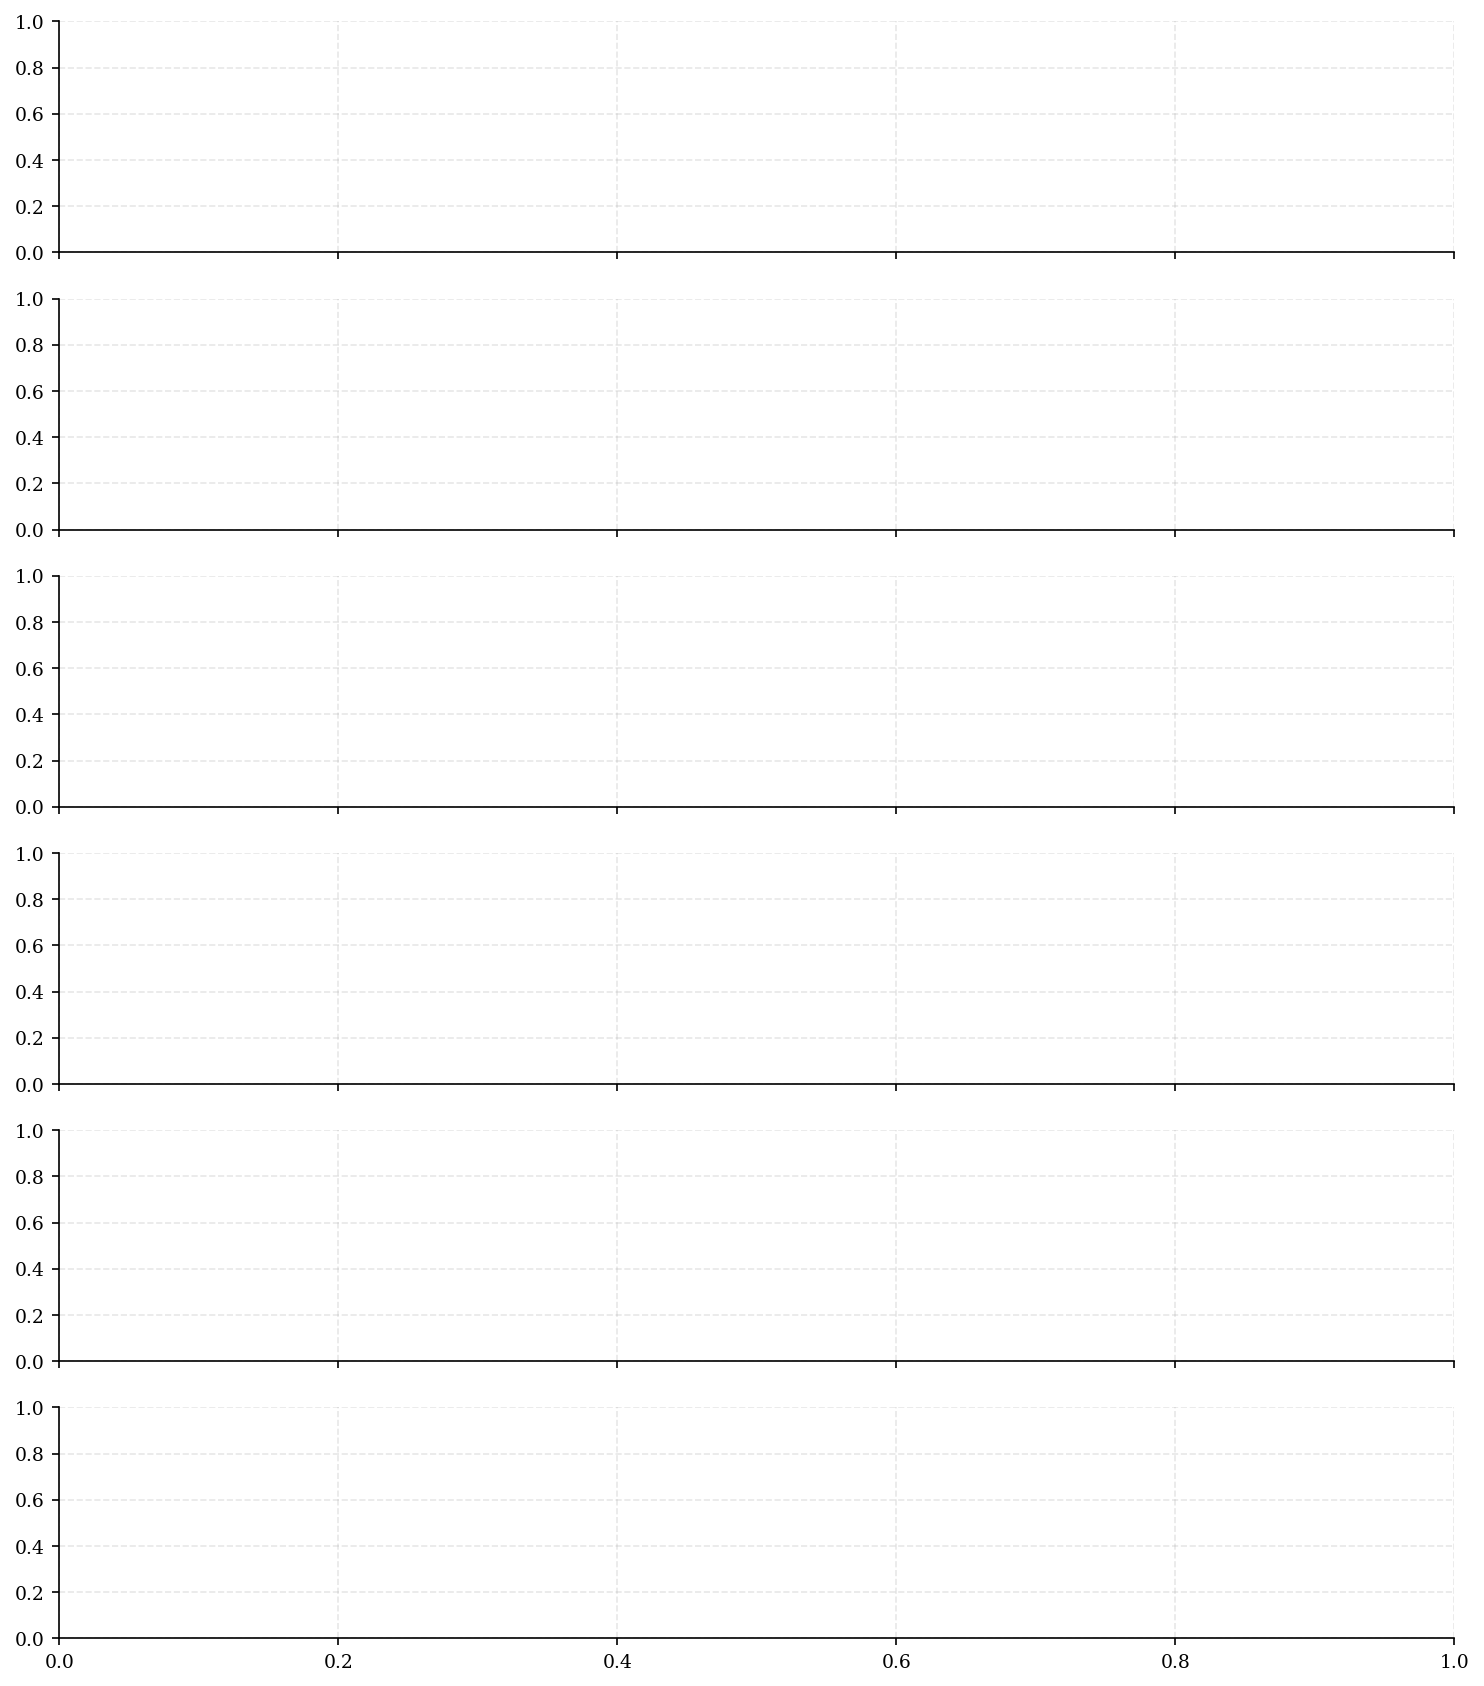

In [15]:
fig, axes = plt.subplots(6, 1, figsize=(12, 14), sharex=True)

for i, dev in enumerate(DEVICES):
    g = df_link[df_link['device_id'] == dev].copy().set_index('time').sort_index()

    # rolling 30-min PDR using total_tx
    g['rx1']   = 1
    rx_roll    = g['rx1'].rolling('30T',  min_periods=1).sum()
    tx_roll    = g['total_tx'].rolling('30T', min_periods=1).sum()
    rpdr       = (rx_roll / tx_roll * 100).clip(0, 100)

    axes[i].plot(rpdr.index, rpdr.values,
                 linewidth=0.4, color=DEVICE_COLORS[i], alpha=0.85)
    axes[i].set_ylabel(f'{dev}\nPDR (%)', fontsize=8)
    axes[i].set_ylim(0, 100)
    axes[i].axhline(y=pdr_link, color='black', lw=0.6, ls=':', alpha=0.5)
    axes[i].set_yticks([0, 50, 100])

axes[-1].set_xlabel('Date')
axes[-1].xaxis.set_major_formatter(
    plt.matplotlib.dates.DateFormatter('%b %Y'))
plt.suptitle(
    f'Fig 7.3 — Rolling 30-min PDR per Device (Sep 2024 – May 2025)\n'
    f'Dotted line = PDR_link campaign mean ({pdr_link:.2f}%)',
    fontsize=10, y=1.01)

fig.tight_layout()
save_fig(fig, 'fig_7_3_rolling_pdr')

## 4 · Fig 7.4 — CO₂ vs Rolling PDR Dual Axis  *(§7.4)*

Dual-axis time series for ED3 (office space).  
Left axis: 2-hour rolling PDR. Right axis: 2-hour rolling CO₂.  
Visually demonstrates the CO₂-PDR anticorrelation — the occupancy effect.

In [16]:
dev = 'ED3'
g = df_link[df_link['device_id'] == dev].copy().set_index('time').sort_index()
g['rx1'] = 1

rpdr  = (g['rx1'].rolling('2H', min_periods=1).sum() /
         g['total_tx'].rolling('2H', min_periods=1).sum() * 100).clip(0,100)
rco2  = g['co2'].rolling('2H', min_periods=1).mean()

fig, ax1 = plt.subplots(figsize=(12, 4))
ax2 = ax1.twinx()

ax1.plot(rpdr.index, rpdr.values,
         color=C['blue'], linewidth=0.5, alpha=0.8, label='PDR (%)')
ax2.plot(rco2.index, rco2.values,
         color=C['orange'], linewidth=0.6, alpha=0.75, label='CO₂ (ppm)')

ax1.set_ylabel('PDR (%)',    color=C['blue'],   fontsize=10)
ax2.set_ylabel('CO₂ (ppm)', color=C['orange'], fontsize=10)
ax1.set_ylim(0, 110)
ax1.set_xlabel('Date')
ax1.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b %Y'))

lines1, labs1 = ax1.get_legend_handles_labels()
lines2, labs2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labs1+labs2, loc='upper right')

ax1.set_title(f'Fig 7.4 — {dev}: Rolling PDR vs CO₂ Concentration (2-hour window)')

fig.tight_layout()
save_fig(fig, 'fig_7_4_co2_vs_pdr_ed3')

ValueError: passed window 2H is not compatible with a datetimelike index

## 5 · Fig 7.5 — PDR by Time of Day  *(§7.3.2)*

Bar chart showing the diurnal reliability cycle.  
PDR is lowest during peak hours — clear evidence of occupancy-driven interference.

In [17]:
bands  = ['night', 'morning', 'peak', 'evening']
xlabs  = ['Night\n(00–06)', 'Morning\n(07–09)', 'Peak\n(10–17)', 'Evening\n(18–23)']
colors_tod = [C['navy'], C['blue'], C['red'], C['orange']]

pdrs_tod = []
for band in bands:
    g = df_link[df_link['e4_time_of_day'] == band]
    pdrs_tod.append(pdr(g))

fig, ax = plt.subplots(figsize=(6, 4.5))
bars = ax.bar(xlabs, pdrs_tod, color=colors_tod,
               width=0.45, alpha=0.88, edgecolor='white')

for bar, v in zip(bars, pdrs_tod):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.03,
            f'{v:.2f}%', ha='center', va='bottom', fontsize=9)

ax.axhline(y=pdr_link, color='black', lw=0.8, ls=':', alpha=0.6,
           label=f'Campaign mean ({pdr_link:.2f}%)')
ax.set_ylabel('PDR_link (%)')
ax.set_title('Fig 7.5 — PDR by Time of Day (E4)')
ax.set_ylim(94, 98)
ax.legend()

fig.tight_layout()
save_fig(fig, 'fig_7_5_time_of_day_pdr')

  Saved: fig_7_5_time_of_day_pdr.pdf + .png


## 6 · Fig 7.6 — CO₂ Tier PDR + Burst Rate  *(§7.4)*

Dual bar chart — PDR (blue, left axis) and burst rate (orange, right axis) per CO₂ tier.  
Shows that high occupancy increases both total losses AND burst severity.

In [18]:
tiers  = ['background', 'moderate', 'high']
xlabs  = ['Background\n(≤500 ppm)', 'Moderate\n(500–700 ppm)', 'High\n(>700 ppm)']

pdrs_co2, bursts_co2 = [], []
for tier in tiers:
    g = df_link[df_link['e1_co2_tier'] == tier]
    pdrs_co2.append(pdr(g))
    bursts_co2.append(burst_rate(g))

x = np.arange(len(tiers)); w = 0.35
fig, ax1 = plt.subplots(figsize=(7, 4.5))
ax2 = ax1.twinx()

b1 = ax1.bar(x - w/2, pdrs_co2,   w, color=C['blue'],   alpha=0.88,
             label='PDR_link (%)', edgecolor='white')
b2 = ax2.bar(x + w/2, bursts_co2, w, color=C['orange'], alpha=0.88,
             label='Burst rate (%)', edgecolor='white')

for bar, v in zip(b1, pdrs_co2):
    ax1.text(bar.get_x()+bar.get_width()/2, v+0.02,
             f'{v:.1f}%', ha='center', va='bottom', fontsize=8)
for bar, v in zip(b2, bursts_co2):
    ax2.text(bar.get_x()+bar.get_width()/2, v+0.001,
             f'{v:.2f}%', ha='center', va='bottom', fontsize=8, color=C['orange'])

ax1.set_xticks(x); ax1.set_xticklabels(xlabs)
ax1.set_ylabel('PDR_link (%)',   color=C['blue'])
ax2.set_ylabel('Burst rate (%)', color=C['orange'])
ax1.set_title('Fig 7.6 — CO₂ Tier: PDR and Burst Rate (E1)')
ax1.set_ylim(93, 98.5)
ax2.set_ylim(0, 0.5)

patches = [mpatches.Patch(color=C['blue'],   label='PDR_link (%)'),
           mpatches.Patch(color=C['orange'], label='Burst rate (%)')]
ax1.legend(handles=patches, loc='lower left')

fig.tight_layout()
save_fig(fig, 'fig_7_6_co2_pdr_burst')

  Saved: fig_7_6_co2_pdr_burst.pdf + .png


## 7 · Fig 7.7 — SF PDR + Burst Rate  *(§7.6.1)*

Dual bar chart showing monotone decrease in PDR and increase in burst rate with SF.  
ToA values annotated on x-axis to make the collision-window relationship explicit.

In [19]:
sfs    = [7, 8, 9, 10]
xlabs  = [f'SF{sf}\n({TOA_MS[sf]}ms)' for sf in sfs]

pdrs_sf, bursts_sf = [], []
for sf in sfs:
    g = df_link[df_link['e13_sf'] == sf]
    pdrs_sf.append(pdr(g))
    bursts_sf.append(burst_rate(g))

x = np.arange(len(sfs)); w = 0.35
fig, ax1 = plt.subplots(figsize=(7, 4.5))
ax2 = ax1.twinx()

b1 = ax1.bar(x - w/2, pdrs_sf,   w, color=C['blue'],   alpha=0.88,
             label='PDR_link (%)', edgecolor='white')
b2 = ax2.bar(x + w/2, bursts_sf, w, color=C['orange'], alpha=0.88,
             label='Burst rate (%)', edgecolor='white')

for bar, v in zip(b1, pdrs_sf):
    ax1.text(bar.get_x()+bar.get_width()/2, v+0.02,
             f'{v:.1f}%', ha='center', va='bottom', fontsize=8)
for bar, v in zip(b2, bursts_sf):
    ax2.text(bar.get_x()+bar.get_width()/2, v+0.001,
             f'{v:.2f}%', ha='center', va='bottom', fontsize=8, color=C['orange'])

ax1.set_xticks(x); ax1.set_xticklabels(xlabs)
ax1.set_ylabel('PDR_link (%)',   color=C['blue'])
ax2.set_ylabel('Burst rate (%)', color=C['orange'])
ax1.set_title('Fig 7.7 — SF PDR and Burst Rate (E13)')
ax1.set_ylim(88, 100)
ax2.set_ylim(0, 0.8)

patches = [mpatches.Patch(color=C['blue'],   label='PDR_link (%)'),
           mpatches.Patch(color=C['orange'], label='Burst rate (%)')]
ax1.legend(handles=patches, loc='upper right')

fig.tight_layout()
save_fig(fig, 'fig_7_7_sf_pdr_burst')

  Saved: fig_7_7_sf_pdr_burst.pdf + .png


## 8 · Fig 7.8 — SF × CO₂ Heatmap — Headline Novel Finding  *(§7.6.2)*

The most important figure in the thesis.  
Green = high PDR, red = low PDR.  
Gap annotation below each CO₂ column shows the widening from 2.71 pp to 4.86 pp.

In [20]:
co2_tiers = ['background', 'moderate', 'high']
sf_tiers  = ['low_sf', 'high_sf']
sf_labels = ['Low SF (7–8)\nToA ≤ 134ms', 'High SF (9–10)\nToA ≥ 247ms']
co2_labels= ['Background CO₂\n(≤500 ppm)', 'Moderate CO₂\n(500–700 ppm)', 'High CO₂\n(>700 ppm)']

matrix = np.zeros((2, 3))
for j, co2 in enumerate(co2_tiers):
    for i, sf in enumerate(sf_tiers):
        g = df_link[(df_link['e14_sf_tier']==sf) & (df_link['e1_co2_tier']==co2)]
        matrix[i, j] = pdr(g)

fig, ax = plt.subplots(figsize=(8, 4))
im = ax.imshow(matrix, cmap='RdYlGn', aspect='auto',
               vmin=matrix.min()-0.5, vmax=matrix.max()+0.5)

# cell annotations
for i in range(2):
    for j in range(3):
        v = matrix[i, j]
        ax.text(j, i, f'{v:.2f}%', ha='center', va='center',
                fontsize=12, fontweight='bold',
                color='white' if v < 95.5 else 'black')

# gap annotations below heatmap
for j, co2 in enumerate(co2_tiers):
    gap = matrix[0, j] - matrix[1, j]
    ax.text(j, 2.05, f'gap = {gap:.2f} pp',
            ha='center', va='bottom', fontsize=8.5,
            color=C['red'], style='italic',
            transform=ax.get_xaxis_transform())

ax.set_xticks([0, 1, 2])
ax.set_xticklabels(co2_labels, fontsize=9)
ax.set_yticks([0, 1])
ax.set_yticklabels(sf_labels, fontsize=9)
ax.set_title(
    'Fig 7.8 — Joint PDR: SF Tier × CO₂ Tier (E14 × E1)\n'
    'Gap widens from 2.71 pp (background) to 4.86 pp (high CO₂) — SF×occupancy interaction confirmed',
    fontsize=10)

cbar = plt.colorbar(im, ax=ax, shrink=0.75)
cbar.set_label('PDR_link (%)', fontsize=9)

fig.tight_layout()
save_fig(fig, 'fig_7_8_sf_co2_heatmap')

  Saved: fig_7_8_sf_co2_heatmap.pdf + .png


## 9 · Fig 7.9 — Logistic Regression Forest Plot  *(§7.7)*

Horizontal forest plot — OR with 95% CI for all event predictors.  
Device fixed effects excluded — only event predictors shown.  
Log scale on x-axis so OR=33 fits without squashing the others.  
Red = higher risk (OR > 1), blue = lower risk (OR < 1).

In [21]:
# event predictors only — exclude device fixed effects
ev = or_table[~or_table['predictor'].str.startswith('device_id_')].copy()
ev = ev.sort_values('OR_loss', ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(9, len(ev)*0.38 + 1.5))

for i, row in ev.iterrows():
    color = C['red'] if row['OR_loss'] > 1 else C['blue']
    # CI line
    ax.plot([row['loss_CI_lo'], row['loss_CI_hi']], [i, i],
            color=color, lw=1.5, alpha=0.7, solid_capstyle='round')
    # OR point
    ax.scatter(row['OR_loss'], i, color=color, s=40, zorder=5)

ax.axvline(x=1.0, color='black', lw=0.8, ls='--', alpha=0.6)
ax.set_yticks(range(len(ev)))
ax.set_yticklabels(ev['predictor'], fontsize=7.5)
ax.set_xlabel('Odds Ratio — loss risk  (log scale)')
ax.set_title('Fig 7.9 — Logistic Regression OR with 95% CI\n(Event predictors only, device fixed effects excluded)')
ax.set_xscale('log')
ax.xaxis.set_major_formatter(mticker.ScalarFormatter())

patches = [
    mpatches.Patch(color=C['red'],  label='↑ higher risk (OR > 1)'),
    mpatches.Patch(color=C['blue'], label='↓ lower risk (OR < 1)'),
]
ax.legend(handles=patches, loc='lower right', fontsize=8)

fig.tight_layout()
save_fig(fig, 'fig_7_9_forest_plot')

  Saved: fig_7_9_forest_plot.pdf + .png


## 10 · Summary

In [22]:
print('All figures generated:')
print()
for f in sorted(FIG_DIR.glob('fig_*.pdf')):
    size_kb = f.stat().st_size // 1024
    print(f'  {f.name:<45} {size_kb:>5} KB')
print(f'\nFolder: {FIG_DIR.resolve()}')
print('\nOverleaf usage:')
print('  Upload the figures/ folder to your Overleaf project')
print('  Reference: \\includegraphics[width=\\textwidth]{figures/fig_7_8_sf_co2_heatmap}')

All figures generated:

  fig_7_1_pdr_decomposition.pdf                    22 KB
  fig_7_2_loss_zone_breakdown.pdf                  23 KB
  fig_7_5_time_of_day_pdr.pdf                      17 KB
  fig_7_6_co2_pdr_burst.pdf                        19 KB
  fig_7_7_sf_pdr_burst.pdf                         16 KB
  fig_7_8_sf_co2_heatmap.pdf                       39 KB
  fig_7_9_forest_plot.pdf                          26 KB

Folder: D:\Thesis\lorawan_master_thesis\figures

Overleaf usage:
  Upload the figures/ folder to your Overleaf project
  Reference: \includegraphics[width=\textwidth]{figures/fig_7_8_sf_co2_heatmap}
